# Fourier Steering

In [7]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn.functional import softmax

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 16

## 0. Task Configuration

In [ ]:
###############################################################################
# SELECT A TASK TO STEER
###############################################################################
TASK = "addition"  # one of: "addition", "weekdays", "months", "hours"
###############################################################################

# ── Per-task color palette ──────────────────────────────────────────────────
import matplotlib as mpl
CMAPS = {
    "weekdays": "Blues",
    "months": "Greens",
    "hours": "Purples",
    "addition": "Reds",
}
CMAP = CMAPS[TASK]
BAR_COLOR = mpl.colormaps[CMAP](0.6)

# ── Probe location, model, hook site ────────────────────────────────────────
from pathlib import Path

# Walk up from the notebook's working directory until we find pyproject.toml.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find repo root (no pyproject.toml above cwd)")
    REPO_ROOT = REPO_ROOT.parent

#####probes folder######
PROBES_BASE = str(REPO_ROOT / "src" / "fourier_probes" / "addition_probes_layer_18_last_token_resid")
FIGS_DIR = REPO_ROOT / "outputs" / "figures" / "fourier_steering"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "meta-llama/Llama-3.1-8B"
HIDDEN_DIM = 4096
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TARGET_LAYER = 18
ACTIVATION_SOURCE = "resid"     
PROBE_POSITION = "last_token"   


####################### Scaling Factor α #######################
# Multiplier on the original Fourier radius when constructing the steering target.
# Each (cos, sin) probe pair defines a 2D plane in activation space; the original
# radius is sqrt(cos² + sin²) of the projected activation. We rotate to the target
# angle and scale the radius by RADIUS_SCALE α 
RADIUS_SCALE = 10 
################################################################

# ── Task definitions 

if TASK == "addition":
    PERIODS = [2, 5, 10, 20, 50, 100]
    A_VALUES = list(range(1, 12))
    B_VALUES = list(range(1, 12))
    TARGET_SUMS = list(range(0, 24))
    ITEMS = [str(s) for s in TARGET_SUMS]
    ITEM_TO_INDEX = {s: i for i, s in enumerate(ITEMS)}
    N_ITEMS = len(ITEMS)
    ITEM_SHORT = ITEMS
    STEER_RAW_SUMS = list(range(0, 24))

    def _sum_to_item(s):
        return str(s)

    def _make_prompts():
        prompts = []
        for a in A_VALUES:
            for b in B_VALUES:
                prompts.append({
                    "label": f"{a}+{b}",
                    "prompt": f"{a}+{b}=",
                    "expected": str(a + b),
                    "raw_sum": a + b,
                })
        return prompts

    def _check_correct(expected, pred):
        return pred.strip() == expected

elif TASK == "weekdays":
    PERIODS = [2, 5, 10]
    DAYS = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    ITEMS = DAYS
    ITEM_TO_INDEX = {d: i for i, d in enumerate(ITEMS)}
    N_ITEMS = len(ITEMS)
    ITEM_SHORT = [d[:3] for d in ITEMS]
    OFFSETS = ["one", "two", "three", "four", "five", "six", "seven", "eight", "nine",
               "ten", "eleven", "twelve", "thirteen", "fourteen"]
    OFFSET_TO_NUM = {w: i + 1 for i, w in enumerate(OFFSETS)}
    STEER_RAW_SUMS = list(range(0, 7))

    def _sum_to_item(s):
        return DAYS[s % 7]

    def _make_prompts():
        prompts = []
        for day in DAYS:
            for offset in OFFSETS:
                raw_sum = ITEM_TO_INDEX[day] + OFFSET_TO_NUM[offset]
                prompts.append({
                    "label": f"{day}+{offset}",
                    "prompt": f"Q: What day is {offset} days after {day}?\nA:",
                    "expected": DAYS[(ITEM_TO_INDEX[day] + OFFSET_TO_NUM[offset]) % 7],
                    "raw_sum": raw_sum,
                })
        return prompts

    def _check_correct(expected, pred):
        return expected.lower() in pred.lower()

elif TASK == "months":
    PERIODS = [2, 5, 10, 20, 50]
    MONTHS = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]
    ITEMS = MONTHS
    ITEM_TO_INDEX = {m: i for i, m in enumerate(ITEMS)}
    MONTH_NUMBER = {m: i + 1 for i, m in enumerate(MONTHS)}
    N_ITEMS = len(ITEMS)
    ITEM_SHORT = [m[:3] for m in ITEMS]
    OFFSETS = ["one", "two", "three", "four", "five", "six",
               "seven", "eight", "nine", "ten", "eleven", "twelve",
               "thirteen", "fourteen", "fifteen", "sixteen",
               "seventeen", "eighteen", "nineteen", "twenty",
               "twenty-one", "twenty-two", "twenty-three", "twenty-four"]
    OFFSET_TO_NUM = {w: i + 1 for i, w in enumerate(OFFSETS)}
    STEER_RAW_SUMS = list(range(1, 13))

    def _sum_to_item(s):
        return MONTHS[(s - 1) % 12]

    def _make_prompts():
        prompts = []
        for month in MONTHS:
            for offset in OFFSETS:
                raw_sum = MONTH_NUMBER[month] + OFFSET_TO_NUM[offset]
                prompts.append({
                    "label": f"{month[:3]}+{offset}",
                    "prompt": f"Q: What month is {offset} months after {month}?\nA:",
                    "expected": MONTHS[(raw_sum - 1) % 12],
                    "raw_sum": raw_sum,
                })
        return prompts

    def _check_correct(expected, pred):
        return expected.lower() in pred.lower()

elif TASK == "hours":
    PERIODS = [2, 5, 10, 20, 50]
    HOURS = [f"{h:02d}" for h in range(24)]
    ITEMS = HOURS
    ITEM_TO_INDEX = {h: i for i, h in enumerate(ITEMS)}
    N_ITEMS = len(ITEMS)
    ITEM_SHORT = ITEMS
    OFFSETS = ["one", "two", "three", "four", "five", "six",
               "seven", "eight", "nine", "ten", "eleven", "twelve",
               "thirteen", "fourteen", "fifteen", "sixteen",
               "seventeen", "eighteen", "nineteen", "twenty",
               "twenty-one", "twenty-two", "twenty-three", "twenty-four",
               "twenty-five", "twenty-six", "twenty-seven", "twenty-eight",
               "twenty-nine", "thirty", "thirty-one", "thirty-two",
               "thirty-three", "thirty-four", "thirty-five", "thirty-six",
               "thirty-seven", "thirty-eight", "thirty-nine", "forty",
               "forty-one", "forty-two", "forty-three", "forty-four",
               "forty-five", "forty-six", "forty-seven", "forty-eight"]
    OFFSET_TO_NUM = {w: i + 1 for i, w in enumerate(OFFSETS)}
    STEER_RAW_SUMS = list(range(0, 24))

    def _sum_to_item(s):
        return HOURS[s % 24]

    def _make_prompts():
        prompts = []
        for hour in HOURS:
            for offset in OFFSETS:
                prompts.append({
                    "label": f"{hour}+{offset}",
                    "prompt": (f"Q: In 24-hour time, it is now {hour}:00. "
                               f"What time will it be in {offset} hours?\n"
                               f"A: In 24-hour time, it will be "),
                    "expected": f"{(int(hour) + OFFSET_TO_NUM[offset]) % 24:02d}",
                    "raw_sum": int(hour) + OFFSET_TO_NUM[offset],
                })
        return prompts

    def _check_correct(expected, pred):
        return pred.strip() == expected

else:
    raise ValueError(f"Unknown task: {TASK}")

# Map each target raw sum to the concept it implies (uses per-task _sum_to_item)
STEER_SUM_TO_ITEM = {s: _sum_to_item(s) for s in STEER_RAW_SUMS}

all_prompts = _make_prompts()
print(f"Task: {TASK} (cmap={CMAP})")
print(f"Device: {DEVICE}")
print(f"Probes: {PROBES_BASE}")
print(f"Layer: {TARGET_LAYER}, Source: {ACTIVATION_SOURCE}, Position: {PROBE_POSITION}")
print(f"Moduli: {PERIODS}, Radius scale: {RADIUS_SCALE}")
print(f"N items: {N_ITEMS}, Total prompts: {len(all_prompts)}")
print(f"Target raw sums: {STEER_RAW_SUMS}")
print(f"Example prompt: {all_prompts[0]['prompt']!r} -> {all_prompts[0]['expected']}")

Task: addition (cmap=Reds)
Device: cuda
Probes: /mnt/polished-lake/home/thalkay/arithmetic-wild/src/fourier_probes/addition_probes_layer_18_last_token_resid
Layer: 18, Source: resid, Position: last_token
Moduli: [2, 5, 10, 20, 50, 100], Radius scale: 10
N items: 24, Total prompts: 121
Target raw sums: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Example prompt: '1+1=' -> 2


## 1. Load model and probes

In [9]:
from causalab.neural.pipeline import LMPipeline
import pyvene as pv

pipeline = LMPipeline(
    MODEL_NAME,
    max_new_tokens=1,
    device=DEVICE,
    dtype=torch.bfloat16,
)
tokenizer = pipeline.tokenizer

PV_COMPONENT = {
    "resid":      "block_output",
    "mlp_input":  "mlp_input",
    "mlp_output": "mlp_output",
}[ACTIVATION_SOURCE]


def _make_iv(intervention_type):
    config = pv.IntervenableConfig([
        pv.RepresentationConfig(
            layer=TARGET_LAYER,
            component=PV_COMPONENT,
            unit="pos",
            max_number_of_units=1,
        ),
    ], intervention_types=intervention_type)
    iv = pv.IntervenableModel(config, pipeline.model)
    iv.set_device(DEVICE)
    return iv

iv_collect = _make_iv(pv.CollectIntervention)
iv_replace = _make_iv(pv.VanillaIntervention)


print(f"Loaded {MODEL_NAME}")
print(f"Pyvene interventions on layer {TARGET_LAYER} component={PV_COMPONENT!r} "
      f"(probes trained on {ACTIVATION_SOURCE})")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded meta-llama/Llama-3.1-8B
Pyvene interventions on layer 18 component='block_output' (probes trained on resid)


In [10]:
def load_probe_weight(probe_dir, period, func_name):
    """Load a single probe's weight vector and bias."""
    path = os.path.join(probe_dir, f"probe_period{period}_{func_name}.pt")
    state_dict = torch.load(path, map_location="cpu", weights_only=True)
    weight = state_dict["linear.weight"].squeeze(0)
    bias = state_dict["linear.bias"].squeeze(0)
    return weight, bias

NEEDS_SPACE = TASK not in ("addition", "hours")
item_token_ids = {}
for item in ITEMS:
    text = (" " + item) if NEEDS_SPACE else item
    toks = tokenizer.encode(text, add_special_tokens=False)
    item_token_ids[item] = toks[0]
    print(f"  {item}: token_id={toks[0]}, decoded={tokenizer.decode(toks[0])!r}")

  0: token_id=15, decoded='0'
  1: token_id=16, decoded='1'
  2: token_id=17, decoded='2'
  3: token_id=18, decoded='3'
  4: token_id=19, decoded='4'
  5: token_id=20, decoded='5'
  6: token_id=21, decoded='6'
  7: token_id=22, decoded='7'
  8: token_id=23, decoded='8'
  9: token_id=24, decoded='9'
  10: token_id=605, decoded='10'
  11: token_id=806, decoded='11'
  12: token_id=717, decoded='12'
  13: token_id=1032, decoded='13'
  14: token_id=975, decoded='14'
  15: token_id=868, decoded='15'
  16: token_id=845, decoded='16'
  17: token_id=1114, decoded='17'
  18: token_id=972, decoded='18'
  19: token_id=777, decoded='19'
  20: token_id=508, decoded='20'
  21: token_id=1691, decoded='21'
  22: token_id=1313, decoded='22'
  23: token_id=1419, decoded='23'


## 2. Run raw-sum Fourier steering

For each prompt, steer to each target raw sum by setting the Fourier angle to
`2π * (target_sum % period) / period` for every period. This means different raw sums
that share the same residue class (e.g. 8 and 15 period 7) get the **same** Fourier
target — the question is whether the model output distinguishes them.

In [11]:
probe_dir = PROBES_BASE  # shared probes are stored flat (no layer/pos nesting)

# Pre-load probe weights for all periods
probe_weights = {}
for period in PERIODS:
    w_sin, b_sin = load_probe_weight(probe_dir, period, "sin")
    w_cos, b_cos = load_probe_weight(probe_dir, period, "cos")
    probe_weights[period] = {
        "w_sin": w_sin.to(device=DEVICE, dtype=torch.bfloat16),
        "w_cos": w_cos.to(device=DEVICE, dtype=torch.bfloat16),
        "b_sin": b_sin.to(device=DEVICE, dtype=torch.bfloat16),
        "b_cos": b_cos.to(device=DEVICE, dtype=torch.bfloat16),
        "norm_sin": w_sin.norm().item(),
        "norm_cos": w_cos.norm().item(),
        "d_sin": (w_sin / w_sin.norm()).to(device=DEVICE, dtype=torch.bfloat16),
        "d_cos": (w_cos / w_cos.norm()).to(device=DEVICE, dtype=torch.bfloat16),
    }
print(f"Loaded {TASK} {ACTIVATION_SOURCE} probes for periods {PERIODS} at layer {TARGET_LAYER}")
print(f"Probe dir: {probe_dir}")

results = []
log_interval = max(1, len(all_prompts) // 20)

for pi, p in enumerate(all_prompts):
    input_ids = tokenizer(p["prompt"], return_tensors="pt")["input_ids"].to(DEVICE)
    last_pos = input_ids.shape[1] - 1
    locs = {"base": [[[last_pos]]]}

    # Base forward pass — capture activation via pv.CollectIntervention
    with torch.no_grad():
        (_, collected), base_out = iv_collect(
            base={"input_ids": input_ids},
            unit_locations=locs,
        )
    base_act = collected[0][0, 0]  # [hidden]

    base_logits = base_out.logits[0, -1].float()
    base_probs = softmax(base_logits, dim=-1)
    base_pred = tokenizer.decode(base_logits.argmax()).strip()

    # Skip prompts the model gets wrong
    if not _check_correct(p["expected"], base_pred):
        if (pi + 1) % log_interval == 0 or pi == 0:
            print(f"[{pi+1}/{len(all_prompts)}] SKIP {p['label']} "
                  f"-> expected={p['expected']}, got={base_pred}")
        continue

    # Compute original radius per period
    period_info = {}
    for period in PERIODS:
        pw = probe_weights[period]
        pred_sin = (pw["w_sin"] @ base_act + pw["b_sin"]).item()
        pred_cos = (pw["w_cos"] @ base_act + pw["b_cos"]).item()
        period_info[period] = {
            "original_radius": np.sqrt(pred_sin**2 + pred_cos**2),
        }

    # Steer to each target raw sum
    steer_results = {}
    for target_sum in STEER_RAW_SUMS:
        patched = base_act.clone()

        for period in PERIODS:
            pw = probe_weights[period]
            info = period_info[period]
            target_theta = 2 * np.pi * (target_sum) / period
            r_target = info["original_radius"] * RADIUS_SCALE
            target_sin = r_target * np.sin(target_theta)
            target_cos = r_target * np.cos(target_theta)

            cur_sin = (pw["w_sin"] @ patched + pw["b_sin"]).item()
            patched += ((target_sin - cur_sin) / pw["norm_sin"]) * pw["d_sin"]

            cur_cos = (pw["w_cos"] @ patched + pw["b_cos"]).item()
            patched += ((target_cos - cur_cos) / pw["norm_cos"]) * pw["d_cos"]

        # Replace the last-token activation via pv.VanillaIntervention
        src = patched.unsqueeze(0).unsqueeze(0).to(torch.bfloat16)
        with torch.no_grad():
            _, out = iv_replace(
                base={"input_ids": input_ids},
                unit_locations=locs,
                source_representations=src,
            )

        logits = out.logits[0, -1].float()
        probs = softmax(logits, dim=-1)
        pred = tokenizer.decode(logits.argmax()).strip()

        item_probs = {item: probs[item_token_ids[item]].item() for item in ITEMS}
        steer_results[target_sum] = {"probs": item_probs, "pred": pred}

    # Base probs for each item
    base_item_probs = {item: base_probs[item_token_ids[item]].item() for item in ITEMS}

    results.append({
        "label": p["label"],
        "expected": p["expected"],
        "raw_sum": p["raw_sum"],
        "base_pred": base_pred,
        "steer_results": steer_results,
        "base_item_probs": base_item_probs,
    })

    if len(results) % max(1, len(all_prompts) // 10) == 0 or len(results) == 1:
        print(f"[{pi+1}/{len(all_prompts)}] {p['label']}={p['expected']} "
              f"(base={base_pred}) [{len(results)} kept]")

print(f"\nDone! Kept {len(results)}/{len(all_prompts)} prompts (base model correct only)")

Loaded addition resid probes for moduli [2, 5, 10, 20, 50, 100] at layer 18
Probe dir: /mnt/polished-lake/home/thalkay/arithmetic-wild/src/fourier_probes/addition_probes_layer_18_last_token_resid
[1/121] 1+1=2 (base=2) [1 kept]
[12/121] SKIP 2+1 -> expected=3, got=1
[14/121] 2+3=5 (base=5) [12 kept]
[27/121] 3+5=8 (base=8) [24 kept]
[39/121] 4+6=10 (base=10) [36 kept]
[52/121] 5+8=13 (base=13) [48 kept]
[66/121] 6+11=17 (base=17) [60 kept]
[78/121] 8+1=9 (base=9) [72 kept]
[91/121] 9+3=12 (base=12) [84 kept]
[105/121] 10+6=16 (base=16) [96 kept]
[117/121] 11+7=18 (base=18) [108 kept]

Done! Kept 112/121 prompts (base model correct only)


## 3. Heatmap: target sum vs P(concept)

Rows = target sum, columns = P(concept).

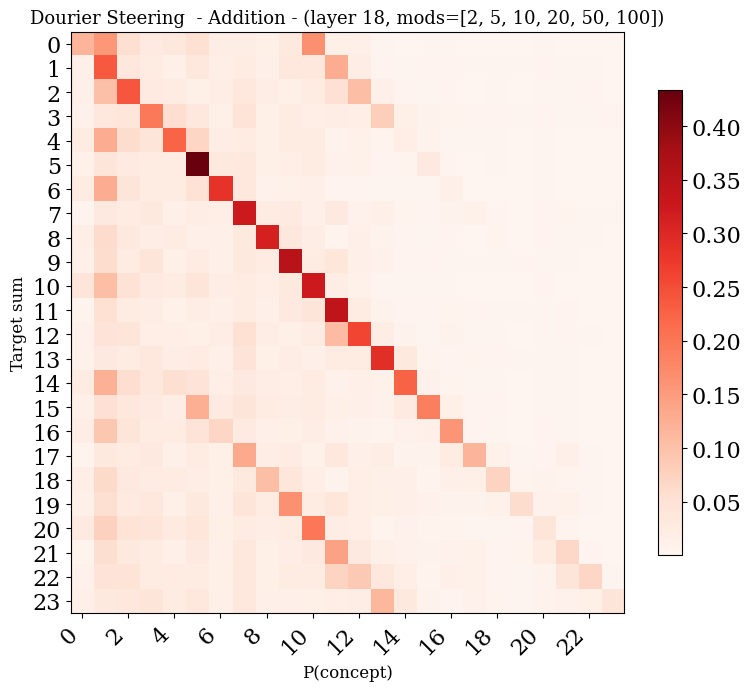

In [12]:
# Build matrix: rows = STEER_RAW_SUMS, cols = ITEMS
# Average across all prompts (including self-steering rows where the
n_sums = len(STEER_RAW_SUMS)
mean_matrix = np.full((n_sums, N_ITEMS), np.nan)

for si, target_sum in enumerate(STEER_RAW_SUMS):
    all_probs = []
    for r in results:
        sr = r["steer_results"][target_sum]
        all_probs.append([sr["probs"][item] for item in ITEMS])
    if all_probs:
        mean_matrix[si] = np.mean(all_probs, axis=0)

# Tick spacing
item_tick_step = max(1, N_ITEMS // 12)
item_tick_pos = list(range(0, N_ITEMS, item_tick_step))
item_tick_labels = [ITEM_SHORT[i] for i in item_tick_pos]

fig, ax = plt.subplots(figsize=(8, max(6, n_sums * 0.3)))
im = ax.imshow(mean_matrix, cmap=CMAP, aspect="auto")
ax.set_yticks(range(n_sums))
if TASK in ("addition", "hours"):
    ax.set_yticklabels([f"{s}" for s in STEER_RAW_SUMS], fontsize=16)
else:
    # months -> "1 (Jan)", weekdays -> "0 (Sat)" — first 3 letters of item
    ax.set_yticklabels([f"{s} ({STEER_SUM_TO_ITEM[s][:3]})" for s in STEER_RAW_SUMS], fontsize=16)

ax.set_xticks(item_tick_pos)

ax.set_xticklabels(item_tick_labels, fontsize=16, rotation=45, ha="right")
ax.set_xlabel("P(concept)", fontsize=12)
ax.set_ylabel("Target sum", fontsize=12)
ax.set_title(f"Fourier Steering  - {TASK.title()} - (layer {TARGET_LAYER}, periods={PERIODS})", fontsize=13)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
fig.savefig(FIGS_DIR / f"{TASK}_mean_prob_matrix_alpha_{RADIUS_SCALE}.pdf", bbox_inches="tight")
plt.show()